In [19]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

import re
# 1. Load GSM8K train split (config "main")
ds = load_dataset("gsm8k", "main", split="train")

df = pd.DataFrame(ds)



In [20]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (7473, 2)
Columns: ['question', 'answer']


,question,answer
0,Natalia sold clips to 48 of her friends in Apr...,Natalia sold 48/2 = <<48/2=24>>24 clips in May...
1,Weng earns $12 an hour for babysitting. Yester...,Weng earns 12/60 = $<<12/60=0.2>>0.2 per minut...
2,Betty is saving money for a new wallet which c...,"In the beginning, Betty has only 100 / 2 = $<<..."
3,"Julie is reading a 120-page book. Yesterday, s...",Maila read 12 x 2 = <<12*2=24>>24 pages today....
4,James writes a 3-page letter to 2 different fr...,He writes each friend 3*2=<<3*2=6>>6 pages a w...


count    7473.000000
mean      234.507427
std        93.904275
min        42.000000
25%       168.000000
50%       217.000000
75%       280.000000
max       985.000000
Name: q_len_chars, dtype: float64


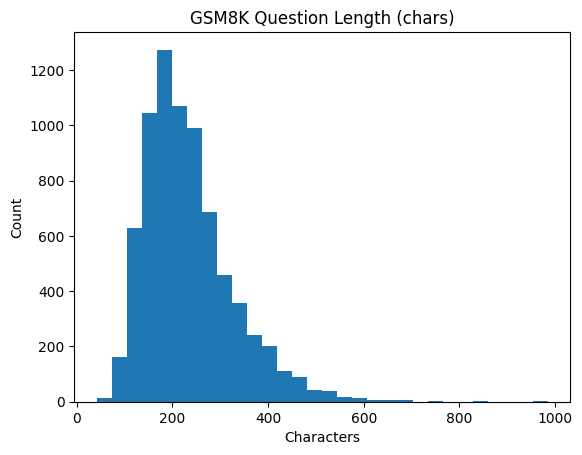

In [21]:
# 3. Question length distribution
df["q_len_chars"] = df["question"].str.len()
print(df["q_len_chars"].describe())
plt.hist(df["q_len_chars"], bins=30)
plt.title("GSM8K Question Length (chars)")
plt.xlabel("Characters"); plt.ylabel("Count")
plt.show()

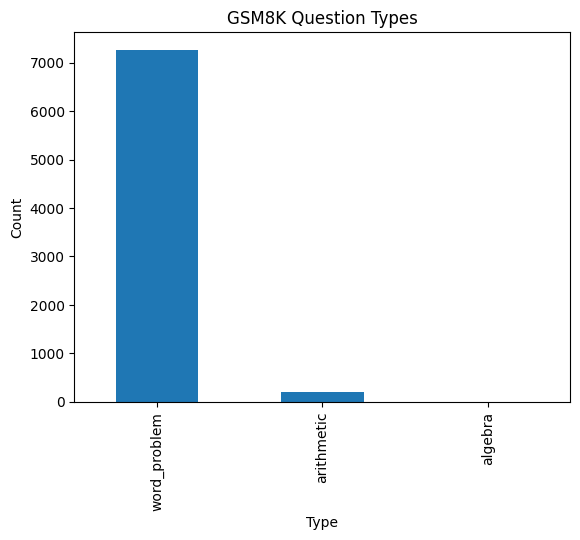

In [23]:
# 4. Question type tagging
def tag_type(q):
    ql = q.lower()
    if re.search(r"\b(algebra|solve for|equation)\b", ql):
        return "algebra"
    if re.search(r"\b(sum|add|subtract|multiply|divide|perimeter|area)\b", ql):
        return "arithmetic"
    return "word_problem"

df["q_type"] = df["question"].apply(tag_type)
df["q_type"].value_counts().plot.bar()
plt.title("GSM8K Question Types")
plt.xlabel("Type"); plt.ylabel("Count")
plt.show()

category
algebra                 1
arithmetic            158
fractions/ratios     1034
geometry              134
percentages/rates    1157
problem_solving      4989
Name: count, dtype: int64


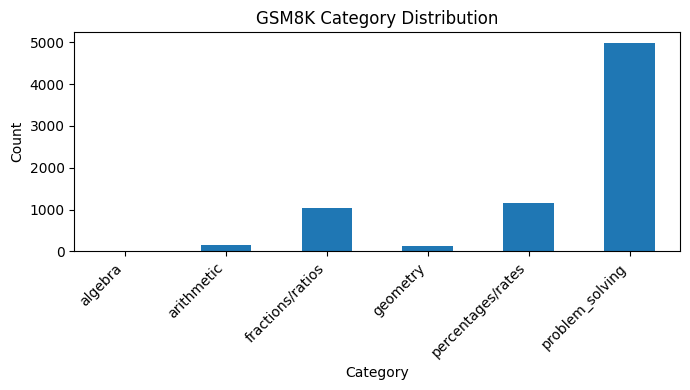

In [29]:

# 2. Define GSM‐centric categories , more suitable for gsm data
def tag_gsm8k_category(q: str) -> str:
    ql = q.lower()
    if re.search(r"\b(sum|add|subtract|multiply|divide)\b", ql):
        return "arithmetic"
    if re.search(r"\bsolve for|equation|x\s*=\b", ql):
        return "algebra"
    if re.search(r"\bhalf|quarter|fraction|ratio\b", ql):
        return "fractions/ratios"
    if re.search(r"%|\bpercent|per\s+(hour|minute|second|km|mile)\b", ql):
        return "percentages/rates"
    if re.search(r"\b(area|perimeter|circle|triangle|square|volume)\b", ql):
        return "geometry"
    # fallback multi‐step if more than one operation word appears
    ops = len(re.findall(r"\b(add|subtract|multiply|divide)\b", ql))
    if ops > 1:
        return "multi_step"
    return "problem_solving"

# 3. Apply and plot
df["category"] = df["question"].apply(tag_gsm8k_category)
counts = df["category"].value_counts().sort_index()

print(counts)
plt.figure(figsize=(7,4))
counts.plot.bar()
plt.title("GSM8K Category Distribution")
plt.xlabel("Category"); plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()